#### Sampling Variability Metrics

Creates table of sampling variability impact on model performance for each watershed and water use type (e.g. public supply, irrigation) for the calibration run. NB: these metrics for US side of watershed only as validation data only covers US side. 
\
\
Currently missing modeled thermoelectric data.

Sampling uncertainty in NSE/KGE performance metrics (Clark et al., 2021, "The Abuse of Popular Performance Metrics in Hydrologic Modeling", WRR)

What it does: 
- Non-overlapping block bootstrap (block = 1 water year) -> 90% tolerance intervals for NSE/KGE (Section 3.3, Appendix A2/A7)
- Jackknife (leave-one-year-out) standard errors (Appendix A2/A6)
- Jackknife-after-bootstrap standard errors on the tolerance interval itself (Efron, 1992; Appendix A3)

Calibration (n=15 years) gets the full bootstrap tolerance interval.
Validation (n=5 years) is too thin for a stable bootstrap distribution, so it reports the jackknife standard error only.

NB: metric of mean estimate (across all runs in emsemble)

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# get filepath
cd = Path.cwd()

out_dir = Path(f"{cd}/Figures")
out_dir.mkdir(parents=True, exist_ok=True)

In [3]:
##### ---------- MANUAL SET UP ----------

scenarios = [
    {
        'scenario': 'calibration',
        'run_dates': {
            'GBSJ': '2026-07-16',
            'LCRR': '2026-07-16',
            'MILK': '2026-07-16',
        }
    }
]

watersheds = ['GBSJ', 'LCRR', 'MILK']

variables = {
    "public_supply": ("public_supply_mil_gal_validation", "public_supply_mil_gal_calibration"),
    "irrigation": ("irrigation_mil_gal_validation", "irrigation_mil_gal_calibration"),
}

periods = {
    "calibration_period": (2000, 2015),
    "validation_period": (2016, 2020),
}

N_BOOT = 1000                 # bootstrap replicates (matches Clark et al., 2021)
MIN_YEARS_FOR_BOOTSTRAP = 10  # below this, bootstrap tolerance intervals are unstable; report jackknife SE instead (see validation_period, n=5)
RNG_SEED = 56897               # set to None for a fresh draw each run

In [6]:
##### ---------- PREP DATA ----------

def prep_data(watershed, scenarios):

    ### ----- PREP USGS VALIDATION DATA -----
    USGS_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/USGS_validation.csv")
    USGS_data.loc[USGS_data["Watershed"] == "GBSJ", "in_us"] = 1
    USGS_data = USGS_data[USGS_data["in_us"] != 0]

    data_for_fig = USGS_data

    ### ----- LOOP OVER SCENARIOS, MERGE EACH ONE IN -----
    all_regions = pd.read_csv('/netfiles/ciroh/cmanitiu/USGS/Data_final/Basin_Boundaries/US_region_list.csv')
    all_regions = all_regions.rename(columns={'huc12': 'HUC12'})

    for s in scenarios:
        scenario = s['scenario']
        run_date = s['run_dates'][watershed]

        model_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/{scenario}-{run_date}.csv")

        model_data = model_data.merge(all_regions, on='HUC12', how='left')
        model_data.loc[model_data["Watershed"] == "GBSJ", "in_us"] = 1
        model_data = model_data[model_data["in_us"] != 0]

        data_for_fig = data_for_fig.merge(model_data, on=['Year', 'Watershed', 'HUC12', 'in_us'], how='outer')

    return data_for_fig


data_for_fig = {w: prep_data(w, scenarios) for w in watersheds}

In [7]:
##### ---------- METRIC FUNCTIONS ----------

def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    denom = np.sum((obs - obs.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((obs - sim) ** 2) / denom


def kge(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    if obs.std() == 0 or obs.mean() == 0:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = sim.std() / obs.std()
    beta = sim.mean() / obs.mean()
    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)


METRIC_FUNCS = {"NSE": nse, "KGE": kge}

##### ---------- RESAMPLING FUNCTIONS ----------

def _pooled(years_draw, obs_by_year, sim_by_year):
    obs = np.concatenate([obs_by_year[y] for y in years_draw])
    sim = np.concatenate([sim_by_year[y] for y in years_draw])
    return obs, sim


def block_bootstrap_tolerance(years, obs_by_year, sim_by_year, metric_func,
                               n_boot=N_BOOT, rng=None):
    rng = rng or np.random.default_rng()
    n = len(years)
    boot_vals = np.empty(n_boot)
    boot_draws = np.empty((n_boot, n), dtype=object)
    for b in range(n_boot):
        sample_years = rng.choice(years, size=n, replace=True)
        boot_draws[b] = sample_years
        obs, sim = _pooled(sample_years, obs_by_year, sim_by_year)
        boot_vals[b] = metric_func(obs, sim)

    valid = boot_vals[~np.isnan(boot_vals)]
    return {
        "boot_mean": np.mean(valid),
        "se_boot": np.std(valid, ddof=1),
        "p05": np.percentile(valid, 5),
        "p95": np.percentile(valid, 95),
        "tolerance_width": np.percentile(valid, 95) - np.percentile(valid, 5),
        "_boot_vals": boot_vals,
        "_boot_draws": boot_draws,
    }


def jackknife_se(years, obs_by_year, sim_by_year, metric_func):
    n = len(years)
    theta_i = np.empty(n)
    for i, y_drop in enumerate(years):
        keep = [y for y in years if y != y_drop]
        obs, sim = _pooled(keep, obs_by_year, sim_by_year)
        theta_i[i] = metric_func(obs, sim)

    valid = ~np.isnan(theta_i)
    n_valid = valid.sum()
    theta_dot = np.mean(theta_i[valid])
    se = np.sqrt((n_valid - 1) / n_valid * np.sum((theta_dot - theta_i[valid]) ** 2))
    return se, theta_dot, theta_i


def jackknife_after_bootstrap(years, boot_vals, boot_draws):
    n = len(years)
    jab_p05 = np.empty(n)
    jab_p95 = np.empty(n)
    for i, y in enumerate(years):
        # subset of bootstrap samples that do NOT contain water year y
        mask = np.array([y not in draw for draw in boot_draws])
        subset = boot_vals[mask]
        subset = subset[~np.isnan(subset)]
        if len(subset) < 10:
            jab_p05[i] = np.nan
            jab_p95[i] = np.nan
            continue
        jab_p05[i] = np.percentile(subset, 5)
        jab_p95[i] = np.percentile(subset, 95)

    def _jack_se(vals):
        valid = ~np.isnan(vals)
        n_valid = valid.sum()
        if n_valid < 2:
            return np.nan
        v_dot = np.mean(vals[valid])
        return np.sqrt((n_valid - 1) / n_valid * np.sum((v_dot - vals[valid]) ** 2))

    return {
        "se_p05_jab": _jack_se(jab_p05),
        "se_p95_jab": _jack_se(jab_p95),
    }

def sampling_uncertainty_for_period(period_df, obs_col, sim_col, metric_name,
                                     min_years_for_bootstrap=MIN_YEARS_FOR_BOOTSTRAP,
                                     n_boot=N_BOOT, rng=None):
    metric_func = METRIC_FUNCS[metric_name]

    obs_by_year, sim_by_year = {}, {}
    for y, grp in period_df.groupby("Year"):
        obs = grp[obs_col].values
        sim = grp[sim_col].values
        mask = ~np.isnan(obs) & ~np.isnan(sim)
        obs, sim = obs[mask], sim[mask]
        if len(obs) > 0:
            obs_by_year[y] = obs
            sim_by_year[y] = sim

    years = sorted(obs_by_year.keys())
    n_years = len(years)
    if n_years < 2:
        return {"n_years": n_years, "method": "insufficient_data"}

    se_jack, theta_jack, _ = jackknife_se(years, obs_by_year, sim_by_year, metric_func)
    point_est = metric_func(*_pooled(years, obs_by_year, sim_by_year))

    result = {
        "n_years": n_years,
        "point_estimate": point_est,
        "se_jackknife": se_jack,
    }

    if n_years >= min_years_for_bootstrap:
        boot = block_bootstrap_tolerance(years, obs_by_year, sim_by_year, metric_func,
                                          n_boot=n_boot, rng=rng)
        jab = jackknife_after_bootstrap(years, boot["_boot_vals"], boot["_boot_draws"])
        result.update({
            "method": "bootstrap_tolerance_interval",
            "se_boot": boot["se_boot"],
            "p05": boot["p05"],
            "p95": boot["p95"],
            "tolerance_width": boot["tolerance_width"],
            "se_p05_jab": jab["se_p05_jab"],
            "se_p95_jab": jab["se_p95_jab"],
        })
    else:
        # too few years (e.g., validation, n=5) for a stable bootstrap
        # distribution -- report the jackknife SE as a +/- interval instead
        result.update({
            "method": "jackknife_se_only",
            "p05": point_est - se_jack,
            "p95": point_est + se_jack,
            "tolerance_width": 2 * se_jack,
        })

    return result

In [8]:
##### ---------- RUN FOR ALL WATERSHEDS / VARIABLES / PERIODS ----------

def compute_sampling_uncertainty(df, watershed, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    rows = []
    for period_name, (y_start, y_end) in periods.items():
        period_df = df[(df["Year"] >= y_start) & (df["Year"] <= y_end)]

        for var_name, (obs_col, sim_col_validation) in variables.items():
            # Option A: collapse the 50-member ensemble to an ensemble-mean
            # simulated value per HUC12-year before resampling years.
            sim_col = sim_col_validation.replace("_validation", "_calibration")
            ens_mean = (
                period_df.groupby(["Year", "HUC12"], as_index=False)[sim_col]
                .mean()
            )
            obs_vals = (
                period_df.groupby(["Year", "HUC12"], as_index=False)[obs_col]
                .first()
            )
            merged = ens_mean.merge(obs_vals, on=["Year", "HUC12"], how="inner")

            for metric_name in METRIC_FUNCS:
                res = sampling_uncertainty_for_period(
                    merged, obs_col, sim_col, metric_name, rng=rng
                )
                res.update({
                    "watershed": watershed,
                    "variable": var_name,
                    "period": period_name,
                    "metric": metric_name,
                })
                rows.append(res)

    return pd.DataFrame(rows)


all_uncertainty = []
for watershed in watersheds:
    df_ws = data_for_fig[watershed]
    all_uncertainty.append(compute_sampling_uncertainty(df_ws, watershed))

uncertainty_df_all = pd.concat(all_uncertainty, ignore_index=True)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)

print("\n=== Sampling uncertainty (90% tolerance interval / jackknife SE), all watersheds ===")
print(uncertainty_df_all)


=== Sampling uncertainty (90% tolerance interval / jackknife SE), all watersheds ===
    n_years  point_estimate  se_jackknife                        method   se_boot       p05       p95  tolerance_width  se_p05_jab  se_p95_jab watershed  \
0        16        0.864561      0.037340  bootstrap_tolerance_interval  0.035997  0.797212  0.909168         0.111956    0.089923    0.007356      GBSJ   
1        16        0.883938      0.040389  bootstrap_tolerance_interval  0.030941  0.816188  0.917021         0.100832    0.037519    0.030301      GBSJ   
2        16        0.513555      0.094578  bootstrap_tolerance_interval  0.093119  0.342032  0.642950         0.300918    0.140241    0.069401      GBSJ   
3        16        0.745979      0.051102  bootstrap_tolerance_interval  0.072374  0.568090  0.797450         0.229360    0.144666    0.045864      GBSJ   
4         5        0.909913      0.003125             jackknife_se_only       NaN  0.906788  0.913037         0.006249         NaN    

In [9]:
##### ---------- BUILD PUBLICATION TABLE ----------

def format_uncertainty_label(row):
    """
    'NSE = 0.75, 90% TI [0.55, 0.85]'  for periods with a bootstrap interval;
    'NSE = 0.75 +/- 0.06 (jackknife SE, n=5 years)' for thin periods.
    """
    if row["method"] == "insufficient_data" or pd.isna(row.get("point_estimate", np.nan)):
        return "\u2013"
    point = row["point_estimate"]
    if row["method"] == "bootstrap_tolerance_interval":
        return f"{point:.2f} [{row['p05']:.2f}, {row['p95']:.2f}]"
    else:
        return f"{point:.2f} \u00b1{row['se_jackknife']:.2f} (n={row['n_years']})"


def format_uncertainty_table_wide(uncertainty_df_all):
    df = uncertainty_df_all.copy()
    df["label"] = df.apply(format_uncertainty_label, axis=1)
    df["Variable"] = df["variable"].str.replace("_", " ").str.title()
    df["Period"] = df["period"].str.replace("_period", "").str.title()

    long_df = df[["watershed", "Variable", "Period", "metric", "label"]].rename(
        columns={"watershed": "Watershed"}
    )

    wide_df = long_df.pivot(
        index=["Watershed", "Variable"], columns=["Period", "metric"], values="label"
    )
    wide_df = wide_df[["Calibration", "Validation"]]

    wide_df = wide_df.reset_index()
    wide_df["Watershed"] = pd.Categorical(wide_df["Watershed"], categories=watersheds, ordered=True)
    wide_df["Variable"] = pd.Categorical(
        wide_df["Variable"], categories=["Public Supply", "Irrigation"], ordered=True
    )
    wide_df = wide_df.sort_values(["Watershed", "Variable"]).reset_index(drop=True)

    return wide_df


table_df = format_uncertainty_table_wide(uncertainty_df_all)
print(table_df)

Period Watershed       Variable          Calibration                             Validation                  
metric                                           NSE                 KGE                NSE               KGE
0           GBSJ  Public Supply    0.86 [0.80, 0.91]   0.88 [0.82, 0.92]   0.91 ±0.00 (n=5)  0.84 ±0.02 (n=5)
1           GBSJ     Irrigation    0.51 [0.34, 0.64]   0.75 [0.57, 0.80]   0.08 ±0.32 (n=5)  0.23 ±0.31 (n=5)
2           LCRR  Public Supply    0.84 [0.80, 0.87]   0.80 [0.75, 0.86]   0.85 ±0.01 (n=5)  0.76 ±0.01 (n=5)
3           LCRR     Irrigation  -0.25 [-0.88, 0.05]  0.39 [-0.10, 0.56]   0.10 ±0.45 (n=5)  0.54 ±0.13 (n=5)
4           MILK  Public Supply    0.92 [0.90, 0.94]   0.95 [0.88, 0.97]   0.92 ±0.00 (n=5)  0.95 ±0.01 (n=5)
5           MILK     Irrigation  -0.06 [-0.24, 0.08]   0.53 [0.45, 0.57]  -0.09 ±0.27 (n=5)  0.48 ±0.16 (n=5)


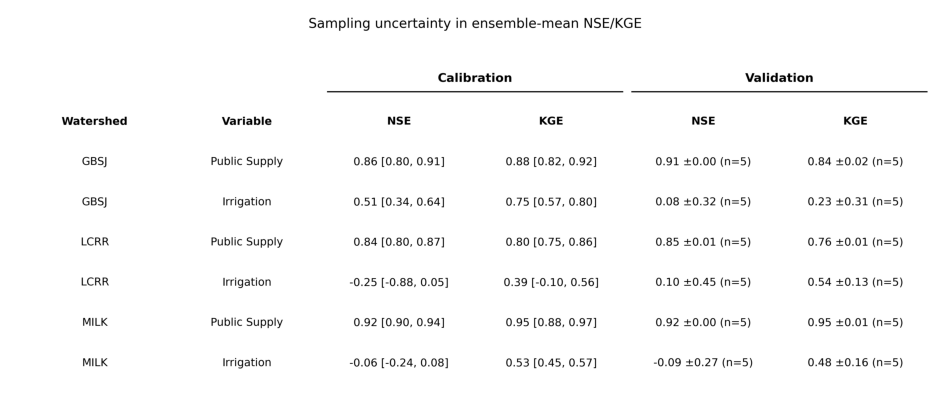

In [12]:
##### ---------- RENDER AS PNG (side-by-side calibration / validation) ----------

def render_table_image_grouped(table_df, out_path, title=None):
    label_cols = [("Watershed", ""), ("Variable", "")]
    metric_col_pairs = [c for c in table_df.columns if c not in label_cols]

    periods_present = list(dict.fromkeys([c[0] for c in metric_col_pairs]))
    metrics_per_period = [c[1] for c in metric_col_pairs if c[0] == periods_present[0]]

    n_rows = len(table_df)
    n_label_cols = len(label_cols)
    n_metric_cols = len(metric_col_pairs)
    n_cols = n_label_cols + n_metric_cols

    fig_width = 1.8 * n_cols
    fig_height = 0.5 * (n_rows + 3)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    metric_header = []
    for col in label_cols:
        metric_header.append(col[0])
    for col in metric_col_pairs:
        metric_header.append(col[1])

    cell_text = table_df.values.tolist()

    tbl = ax.table(
        cellText=cell_text,
        colLabels=metric_header,
        loc="center",
        cellLoc="center",
        bbox=[0, 0, 1, 0.85],
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("none")
        cell.set_text_props(fontfamily="sans-serif")
        if row == 0:
            cell.set_text_props(weight="bold", fontfamily="sans-serif")
            cell.visible_edges = "B"
            cell.set_linewidth(1.0)
        elif row == n_rows:
            cell.visible_edges = "B"
            cell.set_linewidth(1.2)

    start = n_label_cols
    for period in periods_present:
        span = len(metrics_per_period)
        col_idx = start
        ax.text(
            (col_idx + span / 2) / n_cols,
            0.92,
            period,
            ha="center", va="center",
            fontsize=10, fontweight="bold", fontfamily="sans-serif",
            transform=ax.transAxes,
        )
        ax.plot(
            [col_idx / n_cols + 0.005, (col_idx + span) / n_cols - 0.005],
            [0.88, 0.88],
            color="black", linewidth=1.0,
            transform=ax.transAxes,
        )
        start += span

    if title:
        ax.set_title(title, fontsize=11, fontfamily="sans-serif", pad=20)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()


render_table_image_grouped(
    table_df,
    out_path=f"{out_dir}/sampling_uncertainty_table.png",
    title="Sampling uncertainty in ensemble-mean NSE/KGE"
)

img = mpimg.imread(f"{out_dir}/sampling_uncertainty_table.png")
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(img)
ax.axis("off")
plt.show()